# Hotel Booking Demand — Prediction des Annulations par Reseau de Neurones (ANN)

**Variable cible :** `is_canceled` (0 = reservation confirmee, 1 = annulation)
**Dataset :** Hotel Booking Demand (Antonio, Almeida & Nunes, 2019) — 119 390 reservations, 32 variables
**Approche :** ANN (Deep Learning) — Pipeline complet : EDA → Preprocessing → ANN → Evaluation

---

## Section 0 — Contexte & Plan du Notebook

### 0.1 Contexte metier

Les annulations hotelieres representent une perturbation majeure pour la gestion des revenus (Revenue Management). Un taux d'annulation eleve impacte directement la planification des ressources, la strategie de prix, le surbooking et la satisfaction client. Predire avec precision si une reservation sera annulee permet au revenue manager d'ajuster les politiques de depot, de moduler le surbooking et de contacter proactivement les clients a risque.

### 0.2 Problematique Data Science

Predire la variable binaire `is_canceled` a partir des caracteristiques d'une reservation **connues au moment de sa creation**. La contrainte cle est de **ne pas utiliser d'information future** (`reservation_status`, `reservation_status_date`) — ces variables constituent des fuites directes (data leakage).

### 0.3 Plan du notebook

| Section | Contenu |
|---------|---------|
| 1 | Chargement et exploration initiale du dataset |
| 2 | Analyse des valeurs manquantes |
| 3 | Analyse exploratoire approfondie (11 sous-analyses) |
| 4 | Pipeline de preprocessing (data leakage, encoding, outliers, split, scaling, SMOTE) |
| 5 | Modele ANN : architecture, entrainement, evaluation |
| 6 | Importance des features (Random Forest pour interpretabilite) |
| 7 | Conclusion et recommandations metier |

### 0.4 Etudes de reference

- Antonio, Almeida & Nunes (2019) — Etude fondatrice, identification du data leakage
- Herrera et al. (2024) — ANN/MLP/DNN ~86-99% accuracy, justification dropout
- IEEE Xplore (2021) — Ensemble XGBoost+RF optimal comme benchmark
- XAI Stories (Biecek et al.) — Feature engineering `arrival_weekday`, interpretabilite
- arxiv (2024) — `total_of_special_requests` confirmee comme predicteur fort

### 0.5 Bonnes pratiques appliquees

1. Suppression de `reservation_status` et `reservation_status_date` avant tout traitement
2. SMOTE applique **apres** le split (uniquement sur X_train) pour eviter le data leakage
3. StandardScaler fitte **uniquement sur X_train**
4. Split stratifie pour preserver la distribution des classes
5. EarlyStopping et ReduceLROnPlateau pour eviter l'overfitting
6. Random Forest utilise uniquement pour l'importance des features (interpretabilite de l'ANN)

## Imports et Configuration Globale

Toutes les bibliotheques sont importees en un seul bloc. Les constantes du projet (chemins, random state, palette) sont centralisees dans un dictionnaire `CONFIG`.

In [35]:
# Standard library
import os
import json
import time
import warnings
from pathlib import Path
from datetime import datetime

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & evaluation
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix, classification_report
)

# Random Forest uniquement pour l'importance des features
from sklearn.ensemble import RandomForestClassifier

# Reechantillonnage
from imblearn.over_sampling import SMOTE

# Deep Learning (Keras / TensorFlow)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Persistence
import joblib

# Configuration generale
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"TensorFlow   : {tf.__version__}")

NumPy        : 1.26.4
Pandas       : 2.2.2
TensorFlow   : 2.20.0


In [36]:
# -----------------------------------------------------------------------------
# Configuration globale du projet
# -----------------------------------------------------------------------------
CONFIG = {
    # Chemins
    'data_path':     'assets/hotel_bookings.csv',
    'assets_dir':    'assets',
    'models_dir':    'models',

    # Reproductibilite
    'random_state':  42,
    'test_size':     0.2,

    # Palette projet (coherente avec l'application Streamlit)
    'color_primary':   '#1e3a5f',
    'color_secondary': '#2563eb',
    'color_accent':    '#dc2626',
    'color_success':   '#16a34a',
    'color_neutral':   '#64748b',
    'color_bg':        '#f1f5f9',
}

# Creation des dossiers de sortie
Path(CONFIG['models_dir']).mkdir(exist_ok=True)
Path(CONFIG['assets_dir']).mkdir(exist_ok=True)

# Reproductibilite
np.random.seed(CONFIG['random_state'])
tf.random.set_seed(CONFIG['random_state'])

# Style matplotlib / seaborn unifie
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi':       100,
    'savefig.dpi':      150,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'font.family':      'sans-serif',
})

TARGET_PALETTE = {0: CONFIG['color_success'], 1: CONFIG['color_accent']}
TARGET_LABELS  = {0: 'Confirme', 1: 'Annule'}

print("Configuration chargee.")

Configuration chargee.


---

## Section 1 — Chargement et Exploration Initiale

Objectif : prendre la mesure du dataset (volumétrie, types, distribution de la cible) avant toute transformation.

### 1.1 Chargement du dataset

In [39]:
df = pd.read_csv(CONFIG['data_path'])
print(f"Dimensions du dataset : {df.shape[0]:,} lignes  |  {df.shape[1]} colonnes")
df.head(10)

Dimensions du dataset : 119,390 lignes  |  32 colonnes


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,0.0,0,FB,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,0.0,0,HB,PRT,Offline TA/TO,TA/TO,0,0,0,D,D,0,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [40]:
# Dernières lignes (pour vérifier l'homogénéité du fichier)
df.tail(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,0.0,0,HB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


### 1.2 Types de variables

In [42]:
dtype_summary = df.dtypes.value_counts().rename('count').to_frame()
dtype_summary['percentage'] = (dtype_summary['count'] / df.shape[1] * 100).round(1)
print("Répartition des types :")
print(dtype_summary)
print()

numeric_cols     = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Colonnes numériques    ({len(numeric_cols)}) :")
print("  " + ", ".join(numeric_cols))
print()
print(f"Colonnes catégorielles ({len(categorical_cols)}) :")
print("  " + ", ".join(categorical_cols))

Répartition des types :
         count  percentage
int64       16        50.0
object      12        37.5
float64      4        12.5

Colonnes numériques    (20) :
  is_canceled, lead_time, arrival_date_year, arrival_date_week_number, arrival_date_day_of_month, stays_in_weekend_nights, stays_in_week_nights, adults, children, babies, is_repeated_guest, previous_cancellations, previous_bookings_not_canceled, booking_changes, agent, company, days_in_waiting_list, adr, required_car_parking_spaces, total_of_special_requests

Colonnes catégorielles (12) :
  hotel, arrival_date_month, meal, country, market_segment, distribution_channel, reserved_room_type, assigned_room_type, deposit_type, customer_type, reservation_status, reservation_status_date


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### 1.3 Statistiques descriptives — variables numériques

In [45]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.37,0.48,0.00,0.00,0.00,1.0,1.0
lead_time,119390.0,104.01,106.86,0.00,18.00,69.00,160.0,737.0
arrival_date_year,119390.0,2016.16,0.71,2015.00,2016.00,2016.00,2017.0,2017.0
arrival_date_week_number,119390.0,27.17,13.61,1.00,16.00,28.00,38.0,53.0
arrival_date_day_of_month,119390.0,15.80,8.78,1.00,8.00,16.00,23.0,31.0
stays_in_weekend_nights,119390.0,0.93,1.00,0.00,0.00,1.00,2.0,19.0
stays_in_week_nights,119390.0,2.50,1.91,0.00,1.00,2.00,3.0,50.0
adults,119390.0,1.86,0.58,0.00,2.00,2.00,2.0,55.0
children,119386.0,0.10,0.40,0.00,0.00,0.00,0.0,10.0
babies,119390.0,0.01,0.10,0.00,0.00,0.00,0.0,10.0


**Points d'attention à vérifier :**
- `adr` (Average Daily Rate) peut contenir des valeurs négatives ou aberrantes (> 5000) — à corriger en preprocessing
- `lead_time` peut atteindre plusieurs centaines de jours — outliers à capper
- `children` peut contenir des NaN

### 1.4 Statistiques descriptives — variables catégorielles

In [48]:
df.describe(include='object').T

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


In [49]:
# Cardinalité (nombre de valeurs uniques) par variable catégorielle
cardinality = pd.DataFrame({
    'unique_values': [df[c].nunique() for c in categorical_cols],
    'top_value':     [df[c].mode()[0] if not df[c].mode().empty else None for c in categorical_cols],
}, index=categorical_cols).sort_values('unique_values', ascending=False)
cardinality

,unique_values,top_value
reservation_status_date,926,2015-10-21
country,177,PRT
arrival_date_month,12,August
assigned_room_type,12,A
reserved_room_type,10,A
market_segment,8,Online TA
meal,5,BB
distribution_channel,5,TA/TO
customer_type,4,Transient
deposit_type,3,No Deposit


La variable `country` possède une très haute cardinalité (~178 valeurs uniques). Cela impose un encoding adapté (LabelEncoder plutôt que OneHotEncoding pour éviter une explosion dimensionnelle).

### 1.5 Distribution de la variable cible

In [52]:
target_counts = df['is_canceled'].value_counts().sort_index()
target_pct    = (target_counts / len(df) * 100).round(2)
target_summary = pd.DataFrame({
    'count':      target_counts.values,
    'percentage': target_pct.values,
}, index=['Confirmé (0)', 'Annulé (1)'])
print(target_summary)
print(f"\nRatio de déséquilibre : {target_counts[0] / target_counts[1]:.2f} : 1")

              count  percentage
Confirmé (0)  75166       62.96
Annulé (1)    44224       37.04

Ratio de déséquilibre : 1.70 : 1


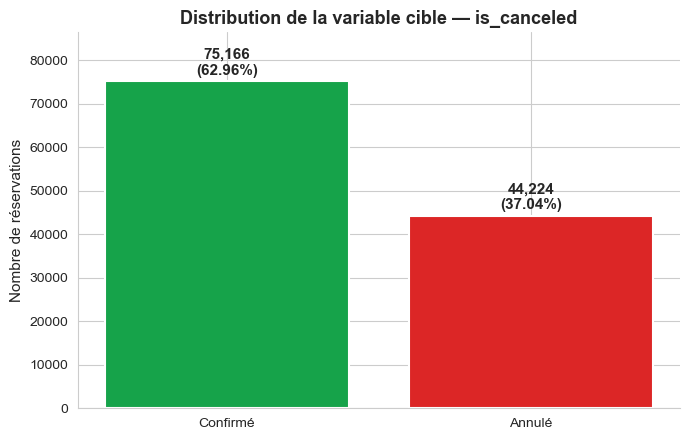

In [53]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(
    ['Confirmé', 'Annulé'],
    target_counts.values,
    color=[CONFIG['color_success'], CONFIG['color_accent']],
    edgecolor='white', linewidth=1.5
)
for bar, pct in zip(bars, target_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 800,
            f'{int(bar.get_height()):,}\n({pct}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Distribution de la variable cible — is_canceled')
ax.set_ylabel('Nombre de réservations')
ax.set_ylim(0, target_counts.max() * 1.15)
plt.tight_layout()
plt.show()

**Interprétation.** Le dataset présente un déséquilibre **modéré** (63% / 37%). Cela ne constitue pas un déséquilibre extrême (où une classe représenterait moins de 10% des données), mais il est suffisamment marqué pour que l'accuracy seule soit trompeuse : un modèle qui prédirait systématiquement « Confirmé » atteindrait déjà 63% d'accuracy sans aucune intelligence. Nous privilégierons donc le **F1-Score macro**, le **ROC-AUC** et le **Recall de la classe 1** (annulations) comme métriques d'évaluation. SMOTE sera appliqué pour rééquilibrer les classes en phase d'entraînement.

---

## Section 2 — Analyse des Valeurs Manquantes

Avant toute modélisation, il est essentiel d'identifier les colonnes avec données manquantes et de définir une stratégie de traitement justifiée.

In [56]:
def compute_missing_summary(data):
    '''Retourne un DataFrame trié des colonnes contenant des valeurs manquantes.'''
    missing_count = data.isnull().sum()
    missing_pct   = (missing_count / len(data) * 100).round(3)
    summary = pd.DataFrame({
        'missing_count':      missing_count,
        'missing_percentage': missing_pct,
    })
    return summary[summary['missing_count'] > 0].sort_values('missing_percentage', ascending=False)

missing_summary = compute_missing_summary(df)
missing_summary

,missing_count,missing_percentage
company,112593,94.307
agent,16340,13.686
country,488,0.409
children,4,0.003


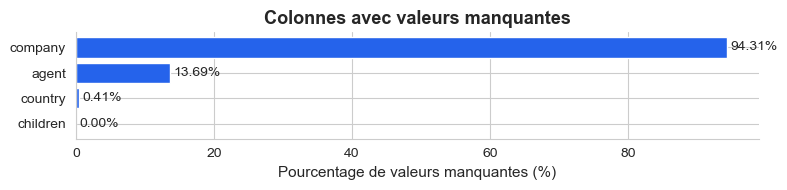

In [57]:
# Visualisation horizontale des valeurs manquantes
fig, ax = plt.subplots(figsize=(8, max(2, 0.5 * len(missing_summary))))
ax.barh(
    missing_summary.index[::-1],
    missing_summary['missing_percentage'][::-1],
    color=CONFIG['color_secondary'],
    edgecolor='white'
)
for i, v in enumerate(missing_summary['missing_percentage'][::-1]):
    ax.text(v + 0.5, i, f'{v:.2f}%', va='center', fontsize=10)
ax.set_xlabel('Pourcentage de valeurs manquantes (%)')
ax.set_title('Colonnes avec valeurs manquantes')
plt.tight_layout()
plt.show()

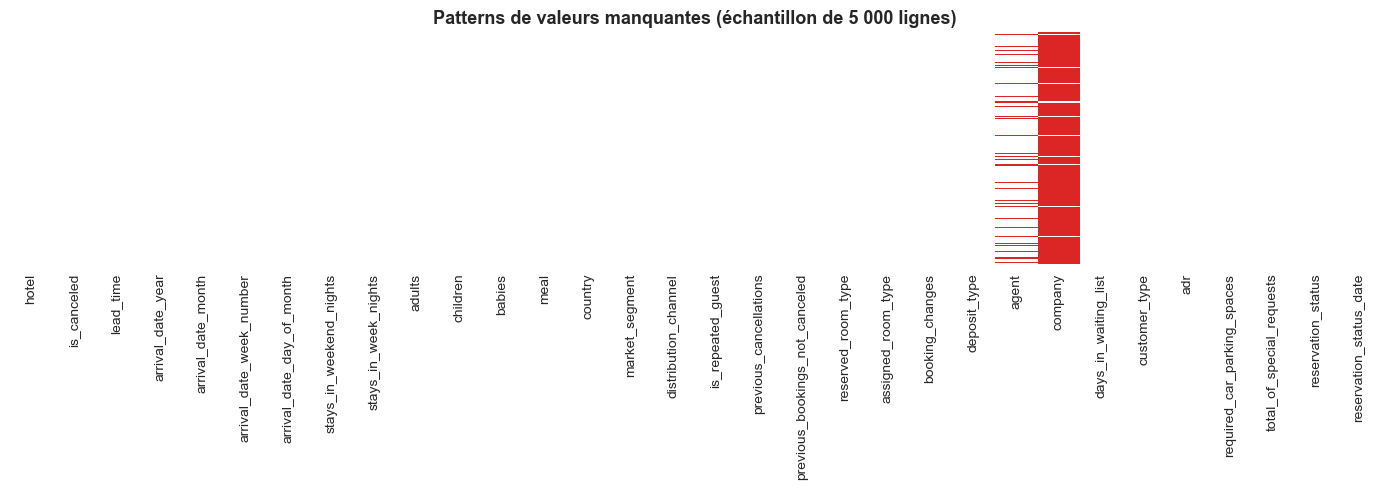

In [58]:
# Heatmap des patterns de co-occurrence (échantillon)
sample = df.sample(5000, random_state=CONFIG['random_state'])
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(sample.isnull(), cbar=False, yticklabels=False,
            cmap=['#ffffff', CONFIG['color_accent']], ax=ax)
ax.set_title('Patterns de valeurs manquantes (échantillon de 5 000 lignes)')
plt.tight_layout()
plt.show()

**Stratégie de traitement (justifiée colonne par colonne) :**

| Colonne | % manquant | Décision | Justification |
|---------|-----------|----------|---------------|
| `company` | ~94% | Supprimer la colonne | Trop de valeurs absentes pour être imputable de façon fiable |
| `agent`   | ~14% | Imputer par 0 | Absence d'agent = réservation directe, information valide |
| `country` | ~0.4% | Imputer par `'Unknown'` | Créer une catégorie explicite plutôt qu'inventer un pays |
| `children`| ~0.003% | Imputer par 0 | Absence d'information = pas d'enfants dans la réservation |

Le traitement effectif sera appliqué dans la Section 4 (Preprocessing), au sein d'un pipeline réutilisable par l'application Streamlit.

---

## Section 3 — Analyse Exploratoire Approfondie (EDA)

Chaque visualisation est accompagnée d'une interprétation. L'objectif est de comprendre les leviers d'annulation **avant** de modéliser, pour confirmer la cohérence métier du modèle final.

In [61]:
# Helper réutilisé dans toute la section 3
def cancellation_rate_by(data, group_col, sort=True):
    '''Calcule le taux d'annulation et le volume par catégorie.'''
    summary = data.groupby(group_col).agg(
        total=('is_canceled', 'count'),
        canceled=('is_canceled', 'sum')
    )
    summary['cancellation_rate'] = (summary['canceled'] / summary['total'] * 100).round(2)
    if sort:
        summary = summary.sort_values('cancellation_rate', ascending=False)
    return summary

### 3.1 Annulations par type d'hôtel

              total  canceled  cancellation_rate
hotel                                           
City Hotel    79330     33102              41.73
Resort Hotel  40060     11122              27.76


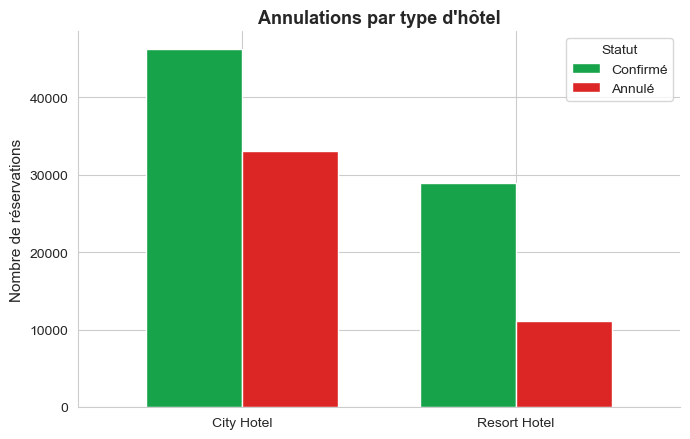

In [63]:
hotel_summary = cancellation_rate_by(df, 'hotel', sort=False)
print(hotel_summary)

fig, ax = plt.subplots(figsize=(7, 4.5))
hotel_pivot = pd.crosstab(df['hotel'], df['is_canceled'])
hotel_pivot.columns = ['Confirmé', 'Annulé']
hotel_pivot.plot(kind='bar', ax=ax,
                 color=[CONFIG['color_success'], CONFIG['color_accent']],
                 edgecolor='white', width=0.7)
ax.set_title('Annulations par type d\'hôtel')
ax.set_xlabel('')
ax.set_ylabel('Nombre de réservations')
ax.legend(title='Statut')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interprétation.** Le City Hotel présente un taux d'annulation systématiquement plus élevé que le Resort Hotel. Cela s'explique par le profil des voyageurs : clientèle d'affaires pour le City Hotel (plans flexibles, changements fréquents) versus clientèle vacancière pour le Resort Hotel (engagement émotionnel plus fort, planification longue). Cette différence justifie l'inclusion de `hotel` comme feature discriminante.

### 3.2 Saisonnalité des annulations

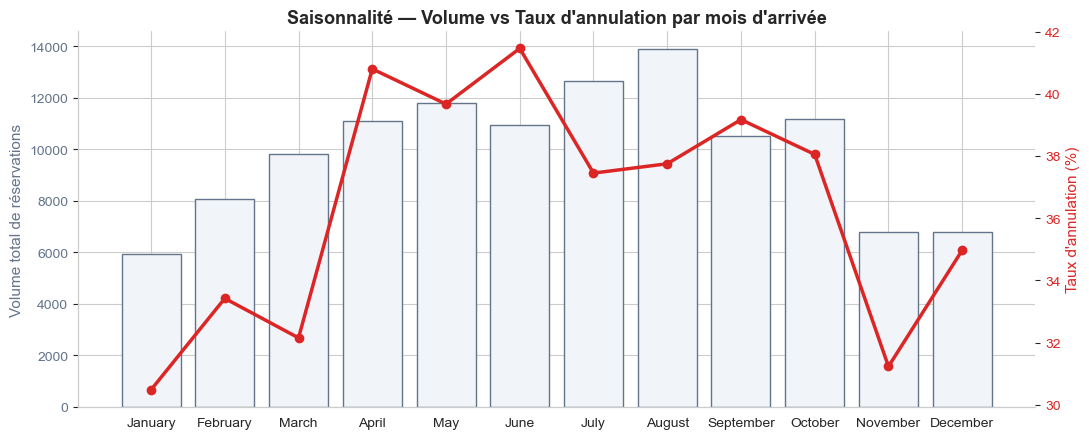

In [66]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly = cancellation_rate_by(df, 'arrival_date_month', sort=False).reindex(month_order)

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.bar(monthly.index, monthly['total'], color=CONFIG['color_bg'],
        edgecolor=CONFIG['color_neutral'], label='Volume total')
ax1.set_ylabel('Volume total de réservations', color=CONFIG['color_neutral'])
ax1.tick_params(axis='y', labelcolor=CONFIG['color_neutral'])

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['cancellation_rate'],
         color=CONFIG['color_accent'], marker='o', linewidth=2.5, label='Taux d\'annulation')
ax2.set_ylabel("Taux d'annulation (%)", color=CONFIG['color_accent'])
ax2.tick_params(axis='y', labelcolor=CONFIG['color_accent'])
ax2.grid(False)

plt.title("Saisonnalité — Volume vs Taux d'annulation par mois d'arrivée")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interprétation.** Les mois d'été (juin à août) concentrent le volume le plus élevé, en cohérence avec la saisonnalité touristique du Portugal. Le taux d'annulation présente un pic en avril–juin, période où les réservations longues sont les plus fréquentes (lead time élevé = risque accru). Inversement, les mois de basse saison combinent volume faible ET taux d'annulation plus modéré, suggérant une clientèle plus engagée (déplacements professionnels).

### 3.3 Lead time et annulation

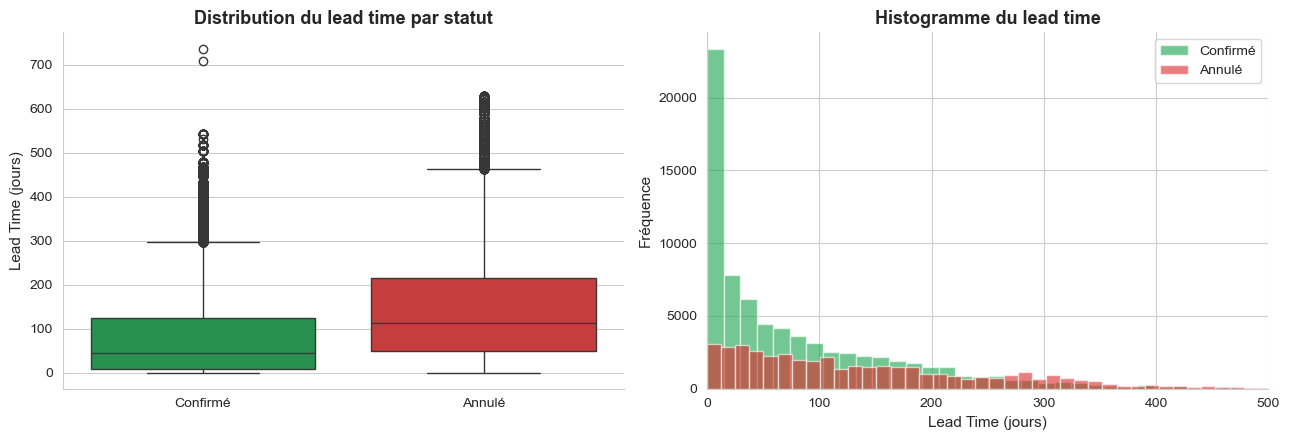


Lead time médian — Confirmé : 45 jours
Lead time médian — Annulé   : 113 jours


In [69]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Boxplot
sns.boxplot(data=df, x='is_canceled', y='lead_time',
            palette=[CONFIG['color_success'], CONFIG['color_accent']], ax=axes[0])
axes[0].set_xticklabels(['Confirmé', 'Annulé'])
axes[0].set_xlabel('')
axes[0].set_ylabel('Lead Time (jours)')
axes[0].set_title('Distribution du lead time par statut')

# Histogramme
for status, color, label in [(0, CONFIG['color_success'], 'Confirmé'),
                              (1, CONFIG['color_accent'], 'Annulé')]:
    axes[1].hist(df.loc[df['is_canceled'] == status, 'lead_time'],
                 bins=50, alpha=0.6, color=color, label=label, edgecolor='white')
axes[1].set_xlabel('Lead Time (jours)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Histogramme du lead time')
axes[1].legend()
axes[1].set_xlim(0, 500)

plt.tight_layout()
plt.show()

print(f"\nLead time médian — Confirmé : {df[df['is_canceled']==0]['lead_time'].median():.0f} jours")
print(f"Lead time médian — Annulé   : {df[df['is_canceled']==1]['lead_time'].median():.0f} jours")

**Interprétation.** Les réservations annulées ont un lead time médian significativement plus élevé que les réservations confirmées. Une réservation faite 300 jours à l'avance est statistiquement plus risquée qu'une réservation faite 7 jours avant l'arrivée. Cela s'explique par l'incertitude croissante à long terme (changements de plans, alternatives découvertes ultérieurement) et par les politiques d'annulation gratuite souvent proposées longtemps avant l'arrivée.

### 3.4 Canal de distribution

                      total  canceled  cancellation_rate
distribution_channel                                    
Undefined                 5         4              80.00
TA/TO                 97870     40152              41.03
Corporate              6677      1474              22.08
GDS                     193        37              19.17
Direct                14645      2557              17.46


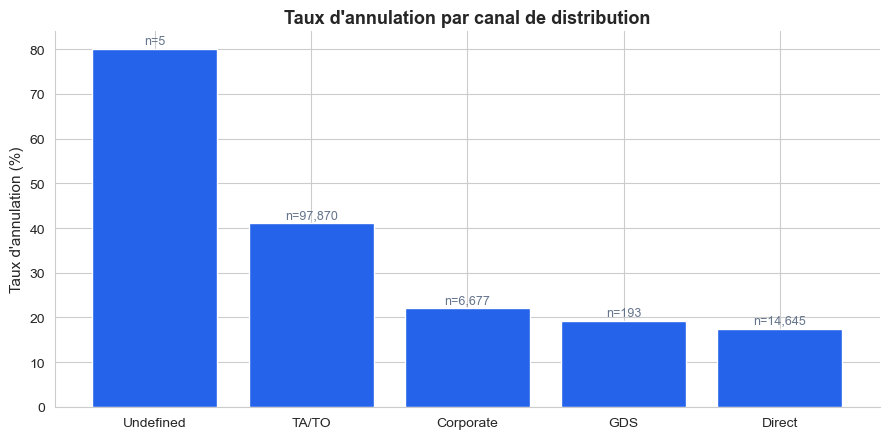

In [72]:
channel_summary = cancellation_rate_by(df, 'distribution_channel')
print(channel_summary)

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(channel_summary.index, channel_summary['cancellation_rate'],
              color=CONFIG['color_secondary'], edgecolor='white')
for bar, total in zip(bars, channel_summary['total']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'n={total:,}', ha='center', va='bottom', fontsize=9, color=CONFIG['color_neutral'])
ax.set_title("Taux d'annulation par canal de distribution")
ax.set_ylabel("Taux d'annulation (%)")
ax.set_xlabel('')
plt.tight_layout()
plt.show()

**Interprétation.** Le canal TA/TO (Travel Agents / Tour Operators) concentre la majorité des annulations en volume comme en taux. Les réservations directes (Direct) présentent le taux d'annulation le plus bas. Cela confirme les résultats de l'étude Herrera (2024) : les OTA et intermédiaires de voyage sont des facteurs de risque majeurs, probablement parce qu'ils encouragent la comparaison et permettent l'annulation facile.

### 3.5 Segment de marché

                total  canceled  cancellation_rate
market_segment                                    
Undefined           2         2             100.00
Groups          19811     12097              61.06
Online TA       56477     20739              36.72
Offline TA/TO   24219      8311              34.32
Aviation          237        52              21.94
Corporate        5295       992              18.73
Direct          12606      1934              15.34
Complementary     743        97              13.06


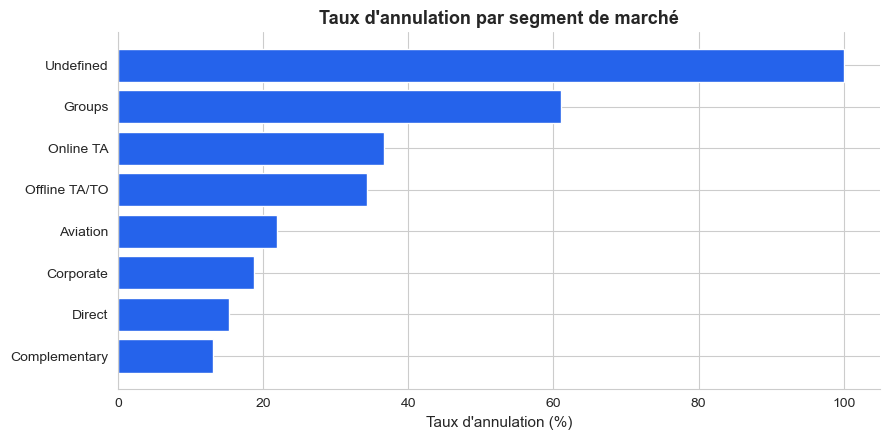

In [75]:
segment_summary = cancellation_rate_by(df, 'market_segment')
print(segment_summary)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(segment_summary.index[::-1], segment_summary['cancellation_rate'][::-1],
        color=CONFIG['color_secondary'], edgecolor='white')
ax.set_xlabel("Taux d'annulation (%)")
ax.set_title("Taux d'annulation par segment de marché")
plt.tight_layout()
plt.show()

**Interprétation.** Le segment **Online TA** domine en volume ET en taux d'annulation. Les segments **Direct** et **Corporate** présentent les taux les plus bas, en cohérence avec une clientèle d'affaires engagée. Les **Groups** ont un comportement intermédiaire mais variable, possiblement lié à la nature des événements (mariages, conférences).

### 3.6 Type de dépôt — Feature critique

               total  canceled  cancellation_rate
deposit_type                                     
No Deposit    104641     29694              28.38
Non Refund     14587     14494              99.36
Refundable       162        36              22.22


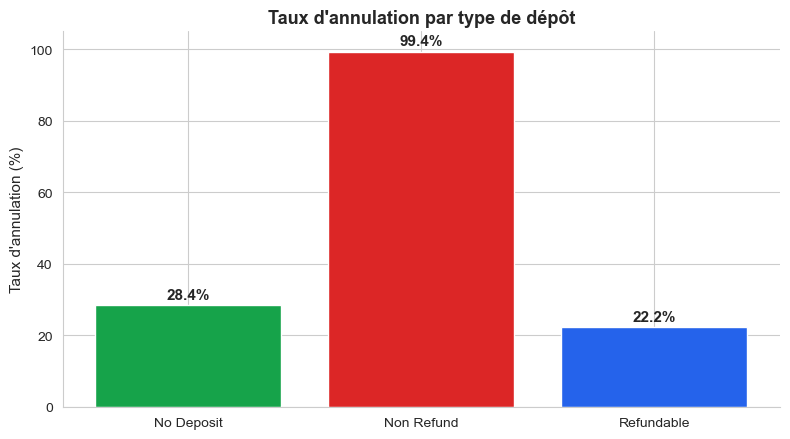

In [78]:
deposit_summary = cancellation_rate_by(df, 'deposit_type', sort=False)
print(deposit_summary)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(deposit_summary.index, deposit_summary['cancellation_rate'],
              color=[CONFIG['color_success'], CONFIG['color_accent'], CONFIG['color_secondary']],
              edgecolor='white')
for bar, rate in zip(bars, deposit_summary['cancellation_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{rate:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title("Taux d'annulation par type de dépôt")
ax.set_ylabel("Taux d'annulation (%)")
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

**Interprétation — paradoxe statistique majeur.** Contre-intuitivement, le type **Non Refund** (dépôt non remboursable) affiche un taux d'annulation proche de 99%. L'explication n'est pas causale mais corrélationnelle : les hôtels appliquent cette politique aux réservations **déjà identifiées comme à risque élevé** (clients suspects, segments connus pour annuler). C'est un cas classique de **biais de sélection** dans les données : ce n'est pas le dépôt non remboursable qui cause l'annulation, mais le profil à risque qui déclenche cette politique. La feature reste néanmoins extrêmement prédictive pour le modèle, et la causalité inversée ne change rien à son utilité statistique.

### 3.7 Clients répétitifs

                 total  canceled  cancellation_rate
Nouveau client  115580     43672              37.79
Client fidèle     3810       552              14.49


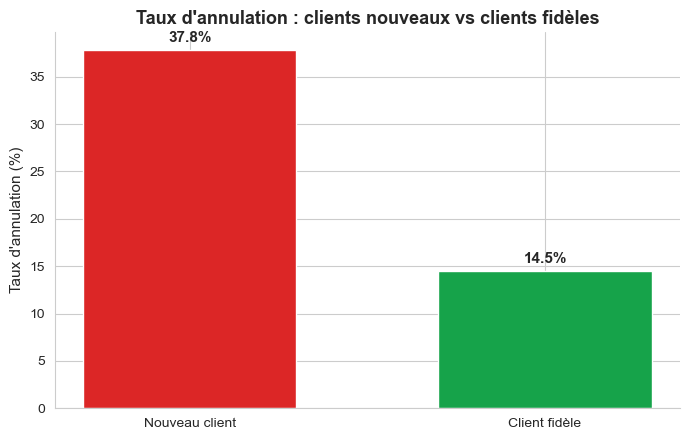

In [81]:
repeat_summary = cancellation_rate_by(df, 'is_repeated_guest', sort=False)
repeat_summary.index = ['Nouveau client', 'Client fidèle']
print(repeat_summary)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(repeat_summary.index, repeat_summary['cancellation_rate'],
              color=[CONFIG['color_accent'], CONFIG['color_success']],
              edgecolor='white', width=0.6)
for bar, rate in zip(bars, repeat_summary['cancellation_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{rate:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title("Taux d'annulation : clients nouveaux vs clients fidèles")
ax.set_ylabel("Taux d'annulation (%)")
plt.tight_layout()
plt.show()

**Interprétation.** Les clients fidèles (`is_repeated_guest = 1`) annulent bien moins souvent que les nouveaux clients. La fidélité est un signal fort d'engagement. Bien que les clients fidèles soient sous-représentés dans le dataset (environ 3-4%), cette feature apporte une valeur discriminante importante pour identifier les profils à faible risque.

### 3.8 Demandes spéciales

                           total  canceled  cancellation_rate
total_of_special_requests                                    
0                          70318     33556              47.72
1                          33226      7318              22.02
2                          12969      2866              22.10
3                           2497       446              17.86
4                            340        36              10.59
5                             40         2               5.00


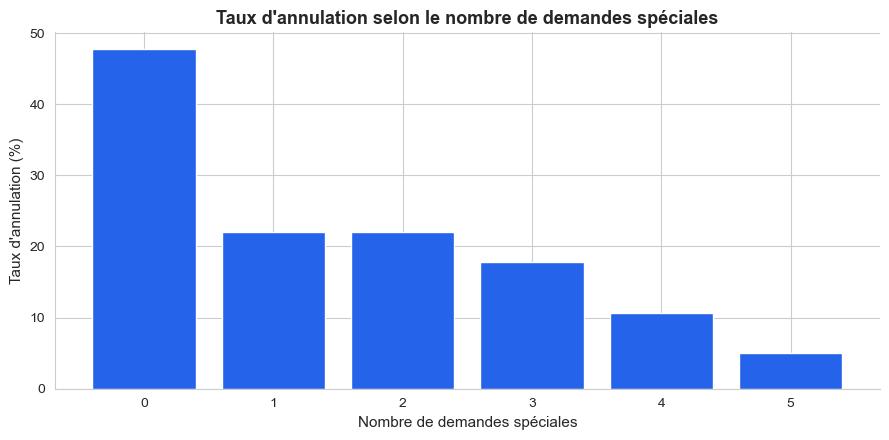

In [84]:
special_summary = cancellation_rate_by(df, 'total_of_special_requests', sort=False)
print(special_summary)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(special_summary.index.astype(str), special_summary['cancellation_rate'],
       color=CONFIG['color_secondary'], edgecolor='white')
ax.set_title("Taux d'annulation selon le nombre de demandes spéciales")
ax.set_xlabel('Nombre de demandes spéciales')
ax.set_ylabel("Taux d'annulation (%)")
plt.tight_layout()
plt.show()

**Interprétation.** Relation inverse nette : plus le nombre de demandes spéciales augmente, plus le taux d'annulation baisse. Chaque demande spéciale représente un investissement cognitif du client dans sa réservation — un signal d'engagement fort. Cette feature est l'une des plus prédictives selon les études bayésiennes (arxiv 2024) et ne doit jamais être supprimée du modèle.

### 3.9 Analyse géographique

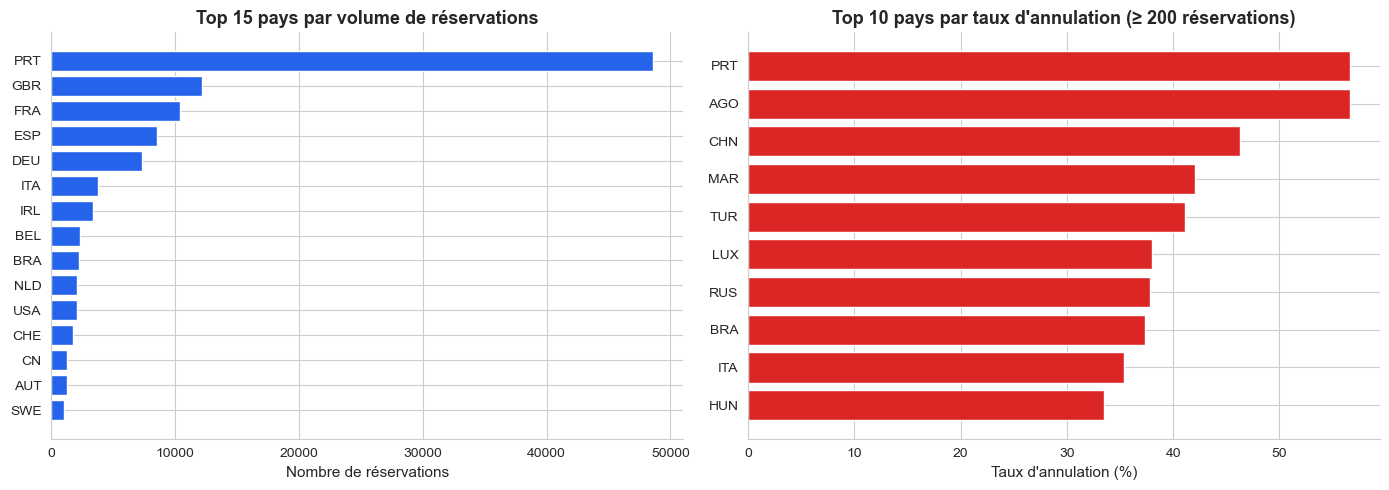

In [87]:
top_countries_volume = df['country'].value_counts().head(15)

# Pour le taux d'annulation : filtrer les pays avec assez de réservations (≥ 200)
country_summary = cancellation_rate_by(df, 'country')
country_summary = country_summary[country_summary['total'] >= 200]
top_countries_rate = country_summary.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_countries_volume.index[::-1], top_countries_volume.values[::-1],
             color=CONFIG['color_secondary'], edgecolor='white')
axes[0].set_title('Top 15 pays par volume de réservations')
axes[0].set_xlabel('Nombre de réservations')

axes[1].barh(top_countries_rate.index[::-1], top_countries_rate['cancellation_rate'][::-1],
             color=CONFIG['color_accent'], edgecolor='white')
axes[1].set_title("Top 10 pays par taux d'annulation (≥ 200 réservations)")
axes[1].set_xlabel("Taux d'annulation (%)")

plt.tight_layout()
plt.show()

**Interprétation.** Le Portugal (PRT) domine logiquement le volume (les deux hôtels sont portugais), suivi par le Royaume-Uni, la France et l'Espagne. Certains pays affichent des taux d'annulation anormalement élevés, possiblement liés aux fuseaux horaires, aux pratiques nationales de réservation ou à une utilisation préférentielle des OTA. La variable `country` a ~178 valeurs uniques — un encodage adapté sera nécessaire.

### 3.10 Analyse de l'ADR (Average Daily Rate)

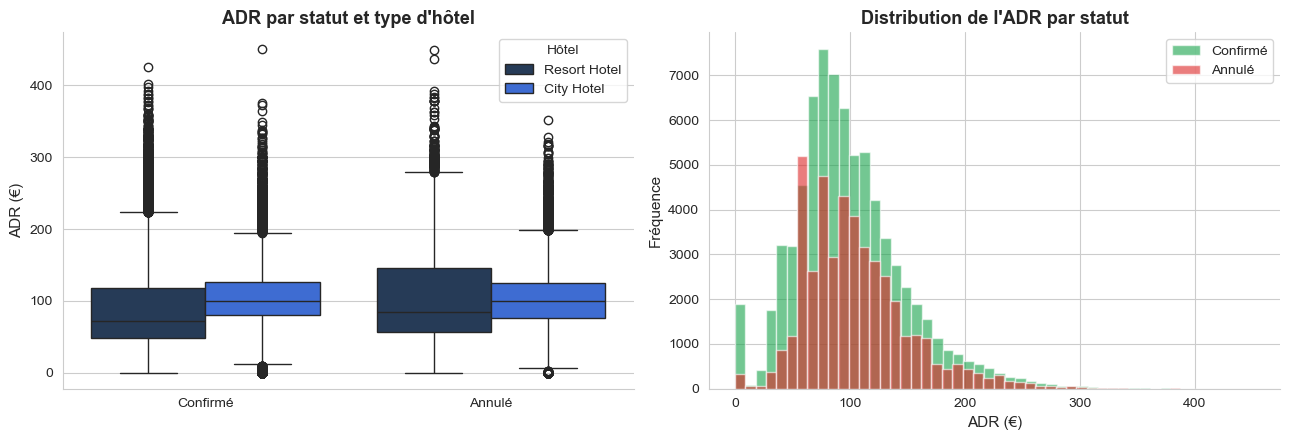

Valeurs négatives d'ADR : 1
Valeurs > 1000          : 1
Valeurs > 5000          : 1


In [90]:
# Filtrer les valeurs aberrantes pour la visualisation uniquement
adr_view = df[(df['adr'] >= 0) & (df['adr'] <= 500)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=adr_view, x='is_canceled', y='adr', hue='hotel',
            palette=[CONFIG['color_primary'], CONFIG['color_secondary']], ax=axes[0])
axes[0].set_xticklabels(['Confirmé', 'Annulé'])
axes[0].set_xlabel('')
axes[0].set_ylabel('ADR (€)')
axes[0].set_title('ADR par statut et type d\'hôtel')
axes[0].legend(title='Hôtel')

for status, color, label in [(0, CONFIG['color_success'], 'Confirmé'),
                              (1, CONFIG['color_accent'], 'Annulé')]:
    axes[1].hist(adr_view.loc[adr_view['is_canceled'] == status, 'adr'],
                 bins=50, alpha=0.6, color=color, label=label, edgecolor='white')
axes[1].set_xlabel('ADR (€)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution de l\'ADR par statut')
axes[1].legend()

plt.tight_layout()
plt.show()

# Anomalies
print(f"Valeurs négatives d'ADR : {(df['adr'] < 0).sum()}")
print(f"Valeurs > 1000          : {(df['adr'] > 1000).sum()}")
print(f"Valeurs > 5000          : {(df['adr'] > 5000).sum()}")

**Interprétation.** Quelques valeurs d'ADR négatives existent — ce sont des erreurs de saisie à corriger. Quelques valeurs extrêmes (> 5000 €) sont également présentes et seront cappées. Les distributions montrent que les réservations à tarif plus élevé sont légèrement plus souvent annulées, possiblement parce qu'elles correspondent à des chambres premium réservées longtemps à l'avance avec des politiques flexibles.

### 3.11 Heatmap de corrélation

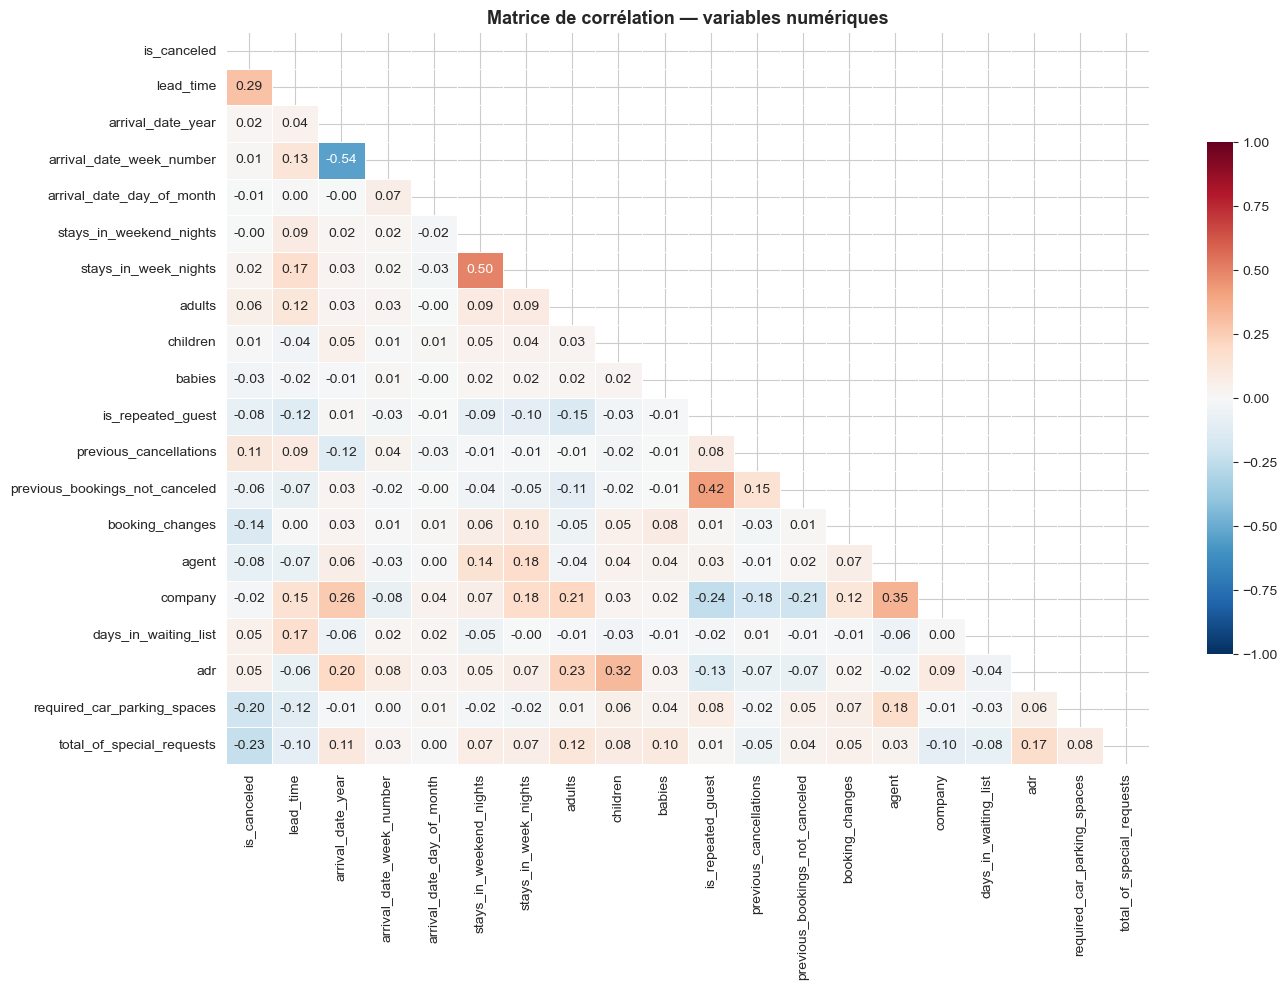


Top 10 corrélations avec is_canceled :
lead_time                         0.293
total_of_special_requests        -0.235
required_car_parking_spaces      -0.195
booking_changes                  -0.144
previous_cancellations            0.110
is_repeated_guest                -0.085
agent                            -0.083
adults                            0.060
previous_bookings_not_canceled   -0.057
days_in_waiting_list              0.054
Name: is_canceled, dtype: float64


In [93]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=False, linewidths=0.5,
            cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Matrice de corrélation — variables numériques')
plt.tight_layout()
plt.show()

# Corrélations avec la cible
target_corr = corr_matrix['is_canceled'].drop('is_canceled').sort_values(key=abs, ascending=False)
print("\nTop 10 corrélations avec is_canceled :")
print(target_corr.head(10).round(3))

**Interprétation.** Les corrélations directes avec `is_canceled` sont modérées (la plus forte ~0.29 pour `lead_time`), ce qui confirme que les relations sont **non linéaires** — d'où l'intérêt d'utiliser un réseau de neurones capable de capturer ces interactions. On observe également de la multicolinéarité entre certaines paires (`adults` / `total_guests`, `stays_in_week_nights` / `total_stays` après feature engineering). Cette multicolinéarité est moins problématique pour les ANN et les forêts aléatoires que pour la régression logistique : les modèles non linéaires distribuent automatiquement le poids entre features corrélées.

---

## Section 4 — Pipeline de Preprocessing

Toutes les transformations sont **encapsulées dans des fonctions modulaires** qui pourront être réimportées telles quelles dans l'application Streamlit (`utils/preprocessing.py`). C'est la garantie que les données reçues en production subiront exactement les mêmes transformations qu'à l'entraînement.

### Plan du pipeline (ordre critique)

1. Suppression des variables de data leakage
2. Imputation des valeurs manquantes
3. Nettoyage des incohérences (réservations à 0 client, ADR négatif, ADR aberrant)
4. Feature engineering (`total_stays`, `total_guests`, `has_special_requests`, `room_type_changed`, `arrival_weekday`)
5. Encodage catégoriel (LabelEncoder pour `country`, OneHot pour le reste)
6. Cappage des outliers (Winsorization à 3 × IQR)
7. Séparation X / y et sauvegarde de la liste des colonnes
8. Split train/test **stratifié**
9. StandardScaler **fitté uniquement sur X_train**
10. SMOTE **uniquement sur X_train**

L'ordre est crucial : SMOTE et StandardScaler doivent être appliqués **après** le split pour éviter tout data leakage entre train et test.

### 4.1 Définition des fonctions de preprocessing

In [97]:
# -----------------------------------------------------------------------------
# Fonctions de preprocessing — réutilisables dans l'application Streamlit
# -----------------------------------------------------------------------------

LEAK_COLS = ['reservation_status', 'reservation_status_date', 'company']


def drop_leakage_columns(data):
    '''Supprime les variables qui fuient l'information cible.'''
    return data.drop(columns=[c for c in LEAK_COLS if c in data.columns])


def handle_missing(data):
    '''Impute les valeurs manquantes selon la stratégie métier validée.'''
    out = data.copy()
    if 'children' in out.columns:
        out['children'] = out['children'].fillna(0)
    if 'country' in out.columns:
        out['country'] = out['country'].fillna('Unknown')
    if 'agent' in out.columns:
        out['agent'] = out['agent'].fillna(0)
    return out


def clean_inconsistencies(data):
    '''Supprime les lignes incohérentes (clients à zéro, ADR aberrant).'''
    out = data.copy()
    # Réservations sans aucun client : erreurs de saisie PMS
    out = out[~((out['adults'] == 0) & (out['children'] == 0) & (out['babies'] == 0))]
    # ADR négatif = erreur
    out = out[out['adr'] >= 0]
    # ADR > 5000 = erreur de saisie (cas isolés)
    out = out[out['adr'] <= 5000]
    return out.reset_index(drop=True)


def engineer_features(data):
    '''Crée les features dérivées identifiées comme utiles par la littérature.'''
    out = data.copy()
    out['total_stays']          = out['stays_in_week_nights'] + out['stays_in_weekend_nights']
    out['total_guests']         = out['adults'] + out['children'] + out['babies']
    out['has_special_requests'] = (out['total_of_special_requests'] > 0).astype(int)
    out['room_type_changed']    = (out['reserved_room_type'] != out['assigned_room_type']).astype(int)
    # arrival_weekday — feature ajoutée d'après l'étude XAI Stories
    out['arrival_weekday'] = pd.to_datetime(
        out['arrival_date_year'].astype(str) + '-' +
        out['arrival_date_month'] + '-' +
        out['arrival_date_day_of_month'].astype(str),
        format='%Y-%B-%d', errors='coerce'
    ).dt.dayofweek.fillna(0).astype(int)
    return out


def encode_categoricals(data, country_encoder=None, fit=True):
    '''
    Encode les variables catégorielles.
    - country : LabelEncoder (haute cardinalité)
    - autres  : One-Hot Encoding
    Retourne (DataFrame encodé, encoder country) pour pouvoir le réutiliser sur du nouveau data.
    '''
    out = data.copy()

    # LabelEncoder pour country
    if fit:
        country_encoder = LabelEncoder()
        out['country_encoded'] = country_encoder.fit_transform(out['country'].astype(str))
    else:
        # Pour les nouveaux pays non vus à l'entraînement : -1
        known = set(country_encoder.classes_)
        out['country_encoded'] = out['country'].astype(str).apply(
            lambda x: country_encoder.transform([x])[0] if x in known else -1
        )
    out = out.drop(columns=['country'])

    # OneHotEncoding pour les autres catégorielles à faible cardinalité
    low_cardinality = [
        'hotel', 'meal', 'market_segment', 'distribution_channel',
        'reserved_room_type', 'assigned_room_type', 'deposit_type',
        'customer_type', 'arrival_date_month'
    ]
    low_cardinality = [c for c in low_cardinality if c in out.columns]
    out = pd.get_dummies(out, columns=low_cardinality, drop_first=True)
    # Conversion booléens issus de get_dummies en int (compatibilité scaler / TF)
    bool_cols = out.select_dtypes(include=['bool']).columns
    out[bool_cols] = out[bool_cols].astype(int)

    return out, country_encoder


def cap_outliers_iqr(data, columns, multiplier=3.0):
    '''Cappe les valeurs au-delà de multiplier x IQR (Winsorization).'''
    out = data.copy()
    for col in columns:
        if col not in out.columns:
            continue
        Q1 = out[col].quantile(0.25)
        Q3 = out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - multiplier * IQR, Q3 + multiplier * IQR
        out[col] = out[col].clip(lower=lower, upper=upper)
    return out

### 4.2 Application du pipeline — étape par étape

In [99]:
print(f"Avant pipeline : {df.shape}")

df_clean = drop_leakage_columns(df)
print(f"Après drop_leakage_columns        : {df_clean.shape}")

df_clean = handle_missing(df_clean)
print(f"Après handle_missing              : {df_clean.shape}  | NaN restants : {df_clean.isnull().sum().sum()}")

df_clean = clean_inconsistencies(df_clean)
print(f"Après clean_inconsistencies       : {df_clean.shape}")

df_clean = engineer_features(df_clean)
print(f"Après engineer_features           : {df_clean.shape}")
print(f"  Nouvelles features : total_stays, total_guests, has_special_requests, room_type_changed, arrival_weekday")

Avant pipeline : (119390, 32)
Après drop_leakage_columns        : (119390, 29)
Après handle_missing              : (119390, 29)  | NaN restants : 0
Après clean_inconsistencies       : (119208, 29)
Après engineer_features           : (119208, 34)
  Nouvelles features : total_stays, total_guests, has_special_requests, room_type_changed, arrival_weekday


In [100]:
df_encoded, country_encoder = encode_categoricals(df_clean, fit=True)
print(f"Après encode_categoricals         : {df_encoded.shape}")

outlier_cols = ['lead_time', 'adr', 'total_stays', 'booking_changes']
df_encoded = cap_outliers_iqr(df_encoded, outlier_cols, multiplier=3.0)
print(f"Après cap_outliers_iqr (×3)       : {df_encoded.shape}")
print(f"  Outliers cappés sur : {outlier_cols}")

Après encode_categoricals         : (119208, 75)
Après cap_outliers_iqr (×3)       : (119208, 75)
  Outliers cappés sur : ['lead_time', 'adr', 'total_stays', 'booking_changes']


### 4.3 Séparation features / cible et sauvegarde des colonnes

La liste **exacte et ordonnée** des colonnes est sauvegardée pour garantir que l'application Streamlit présentera ses features dans le même ordre que celui vu par le modèle à l'entraînement. C'est l'une des sources de bug les plus fréquentes en production.

In [102]:
y = df_encoded['is_canceled'].astype(int)
X = df_encoded.drop(columns=['is_canceled'])

feature_columns = list(X.columns)
joblib.dump(feature_columns, os.path.join(CONFIG['models_dir'], 'feature_columns.pkl'))

print(f"X.shape = {X.shape}   |   y.shape = {y.shape}")
print(f"Nombre de features : {len(feature_columns)}")
print(f"Sauvegardé dans    : {CONFIG['models_dir']}/feature_columns.pkl")

X.shape = (119208, 74)   |   y.shape = (119208,)
Nombre de features : 74
Sauvegardé dans    : models/feature_columns.pkl


### 4.4 Split stratifié train/test

In [104]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=CONFIG['test_size'],
    random_state=CONFIG['random_state'],
    stratify=y
)

print(f"Train : {X_train.shape[0]:,} lignes  |  Test : {X_test.shape[0]:,} lignes")
print()
print("Vérification — distribution des classes préservée :")
print(f"  Train : {y_train.value_counts(normalize=True).round(4).to_dict()}")
print(f"  Test  : {y_test.value_counts(normalize=True).round(4).to_dict()}")

Train : 95,366 lignes  |  Test : 23,842 lignes

Vérification — distribution des classes préservée :
  Train : {0: 0.6292, 1: 0.3708}
  Test  : {0: 0.6292, 1: 0.3708}


### 4.5 Normalisation (StandardScaler) — fittée uniquement sur X_train

In [106]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, os.path.join(CONFIG['models_dir'], 'scaler.pkl'))
joblib.dump(country_encoder, os.path.join(CONFIG['models_dir'], 'label_encoder_country.pkl'))

print(f"X_train_scaled : moyenne ≈ {X_train_scaled.mean():.3f}   écart-type ≈ {X_train_scaled.std():.3f}")
print(f"X_test_scaled  : moyenne ≈ {X_test_scaled.mean():.3f}   écart-type ≈ {X_test_scaled.std():.3f}")
print("Scaler et LabelEncoder sauvegardés.")

X_train_scaled : moyenne ≈ -0.000   écart-type ≈ 0.993
X_test_scaled  : moyenne ≈ 0.001   écart-type ≈ 1.004
Scaler et LabelEncoder sauvegardés.


**Pourquoi cette règle est critique.** Fitter le scaler sur l'ensemble complet avant le split constitue du **data leakage statistique** : le modèle « voit » indirectement les moyennes et écarts-types du test set pendant l'entraînement. L'accuracy ainsi obtenue est artificielle et s'effondre en production. La règle est non-négociable : `fit_transform` sur train, `transform` (sans fit) sur test.

### 4.6 Rééquilibrage par SMOTE — uniquement sur X_train

In [109]:
print(f"Avant SMOTE : {pd.Series(y_train).value_counts().to_dict()}")

smote = SMOTE(random_state=CONFIG['random_state'], k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Après SMOTE : {pd.Series(y_train_resampled).value_counts().to_dict()}")
print(f"Dimensions finales d'entraînement : {X_train_resampled.shape}")

Avant SMOTE : {0: 60008, 1: 35358}
Après SMOTE : {1: 60008, 0: 60008}
Dimensions finales d'entraînement : (120016, 74)


**Pourquoi SMOTE après le split.** SMOTE crée des exemples synthétiques par interpolation entre voisins. Si on l'applique avant le split, des points synthétiques générés à partir d'observations qui finiront dans le test set fuiront indirectement leur information dans le train set. C'est documenté comme erreur récurrente dans la littérature (Towards Data Science 2025). La règle est : split → scale (fit sur train) → SMOTE (sur train uniquement).

---

## Section 5 — Modele ANN : Reseau de Neurones Artificiel

L'approche choisie est un **Reseau de Neurones Artificiel (ANN)** avec 3 couches cachees. Ce choix est justifie par :

- La **non-linearite** des relations entre features et cible (correlations directes moderees ~0.29 — Section 3.11)
- La capacite des ANN a capturer des **interactions complexes** entre les features
- Les resultats de la litterature : Herrera (2024) montre que les ANN/MLP atteignent ~86-99% sur ce dataset
- La **generalisation** sur de nouveaux exemples grace aux mecanismes de regularisation (Dropout, BatchNorm, EarlyStopping)

### 5.1 Architecture du reseau

L'architecture suit une **pyramide decroissante** (128 → 64 → 32 neurones) inspiree de Herrera et al. (2024) :
- **Couche large initiale** pour capturer la diversite des patterns
- **Compression progressive** vers une representation abstraite de haut niveau
- **BatchNormalization** apres chaque couche dense pour stabiliser l'entrainement
- **Dropout** pour la regularisation (prevention de l'overfitting)

In [112]:
def build_ann(input_dim, dropout_rate=0.3):
    '''
    Architecture ANN a 3 couches cachees avec BatchNorm + Dropout.
    Inspiree de Herrera et al. (2024).

    Parametres
    ----------
    input_dim    : nombre de features apres preprocessing
    dropout_rate : taux de desactivation aleatoire des neurones (30% par defaut)
    '''
    model = Sequential([
        # Couche dense 1 : 128 neurones — capture la diversite initiale des patterns
        Dense(128, activation='relu', input_dim=input_dim),
        BatchNormalization(),      # Stabilise et accelere l'entrainement
        Dropout(dropout_rate),     # Regularisation : desactive 30% des neurones

        # Couche dense 2 : 64 neurones — compression progressive
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(dropout_rate),

        # Couche dense 3 : 32 neurones — representation abstraite de haut niveau
        Dense(32, activation='relu'),
        Dropout(0.2),              # Regularisation finale plus legere

        # Couche de sortie : 1 neurone sigmoid — probabilite d'annulation [0, 1]
        Dense(1, activation='sigmoid')
    ])
    return model

ann_model = build_ann(input_dim=X_train_resampled.shape[1])
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         9,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,737 (81.00 KB)

 Trainable params: 20,353 (79.50 KB)

 Non-trainable params: 384 (1.50 KB)

**Justification de chaque composant :**

| Composant | Role |
|-----------|------|
| `Dense(128, relu)` | Capacite initiale large pour capturer la diversite des patterns de reservation |
| `BatchNormalization` | Normalise les activations par mini-batch — stabilise l'entrainement, attenue le covariate shift interne |
| `Dropout(0.3)` | Regularisation — desactive 30% des neurones a chaque batch, force le reseau a ne pas sur-specialiser |
| `Dense(64) -> Dense(32)` | Compression progressive vers une representation abstraite — principe d'encodage hierarchique |
| `Dense(1, sigmoid)` | Sortie probabiliste en [0,1] adaptee a la classification binaire — seuil de decision a 0.5 par defaut |

### 5.2 Compilation du modele

In [115]:
ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
print("Modele compile.")
print(f"  Optimiseur : Adam (lr=0.001)")
print(f"  Loss       : binary_crossentropy")
print(f"  Metriques  : accuracy, AUC")

Modele compile.
  Optimiseur : Adam (lr=0.001)
  Loss       : binary_crossentropy
  Metriques  : accuracy, AUC


**Choix de l'optimiseur Adam :** Adaptatif par parametre (combine RMSprop + momentum), convergence rapide et robuste aux hyperparametres. lr=0.001 est la valeur de reference qui sera reduite automatiquement par ReduceLROnPlateau si necessite.

**Choix de la binary_crossentropy :** Standard pour la classification binaire avec sortie sigmoide. Penalise plus fortement les predictions tres confiantes et fausses — encourage la calibration des probabilites.

### 5.3 Callbacks — EarlyStopping et ReduceLROnPlateau

In [118]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,                # Arret si pas de progres pendant 10 epochs
        restore_best_weights=True,  # Restaure les poids du meilleur etat
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,    # Divise le learning rate par 2
        patience=5,    # Apres 5 epochs sans progression
        min_lr=1e-6,   # Learning rate minimum
        verbose=1
    )
]
print("Callbacks configures :")
print("  EarlyStopping     — arret si val_loss ne progresse pas pendant 10 epochs")
print("  ReduceLROnPlateau — divise lr par 2 si stagnation pendant 5 epochs")

Callbacks configures :
  EarlyStopping     — arret si val_loss ne progresse pas pendant 10 epochs
  ReduceLROnPlateau — divise lr par 2 si stagnation pendant 5 epochs


**Pourquoi ces deux callbacks sont complementaires :**
- **EarlyStopping** determine QUAND arreter l'entrainement (quand la loss de validation cesse de s'ameliorer), et restaure les poids du meilleur etat — evite l'overfitting.
- **ReduceLROnPlateau** reduit le learning rate quand l'apprentissage stagne, permettant une convergence plus fine avant que EarlyStopping ne s'active.

Ces deux mecanismes remplacent avantageusement un nombre fixe d'epochs : le modele s'arrete au bon moment, ni trop tot (underfitting), ni trop tard (overfitting).

### 5.4 Entrainement

In [121]:
history = ann_model.fit(
    X_train_resampled, y_train_resampled,
    epochs=100,
    batch_size=256,
    validation_split=0.2,   # 20% du train pour la validation (monitoring)
    callbacks=callbacks,
    verbose=1
)
print(f"\nEntrainement termine apres {len(history.history['loss'])} epochs.")
print(f"Meilleure val_loss : {min(history.history['val_loss']):.4f}")

Epoch 1/100
376/376 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7811 - auc: 0.8487 - loss: 0.4488 - val_accuracy: 0.6989 - val_auc: 0.0000e+00 - val_loss: 0.4706 - learning_rate: 0.0010
Epoch 2/100
376/376 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8117 - auc: 0.8905 - loss: 0.3843 - val_accuracy: 0.7160 - val_auc: 0.0000e+00 - val_loss: 0.4595 - learning_rate: 0.0010
Epoch 3/100
376/376 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8229 - auc: 0.9009 - loss: 0.3673 - val_accuracy: 0.7323 - val_auc: 0.0000e+00 - val_loss: 0.4468 - learning_rate: 0.0010
Epoch 4/100
376/376 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8281 - auc: 0.9064 - loss: 0.3581 - val_accuracy: 0.7465 - val_auc: 0.0000e+00 - val_loss: 0.4312 - learning_rate: 0.0010
Epoch 5/100
376/376 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8324 - auc: 0.9108 - loss: 0.3504 - val_accuracy: 0.7584 - val_auc: 0.0000e+00 - val_loss: 0.4281 - learning_rate: 0.0010
Epoch 6/100
376/376 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - 

### 5.5 Courbes d'apprentissage

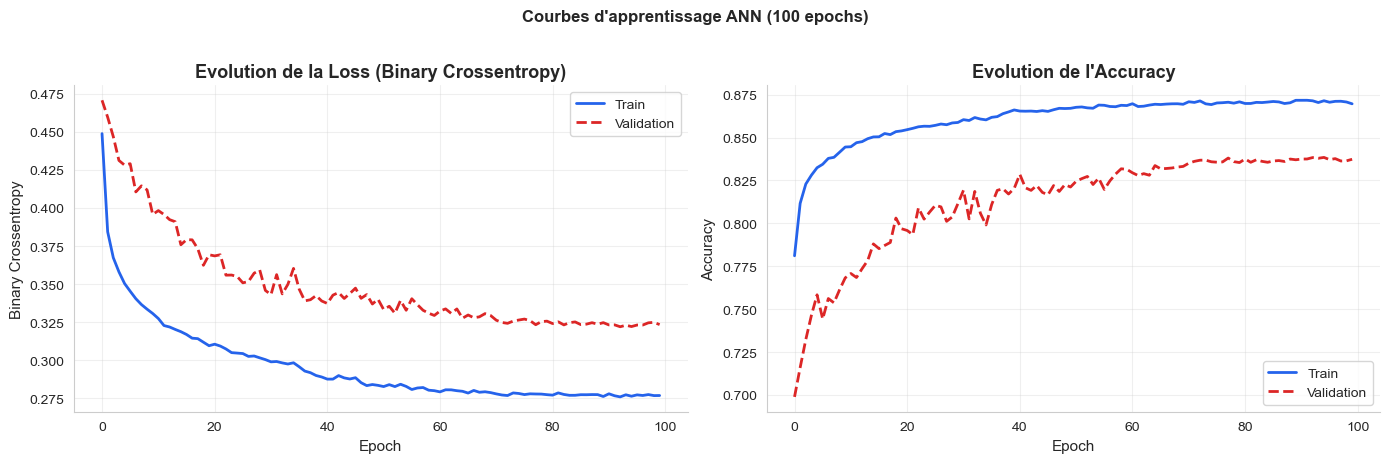

In [123]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Courbe de loss
ax1.plot(history.history['loss'], label='Train', color=CONFIG['color_secondary'], lw=2)
ax1.plot(history.history['val_loss'], label='Validation',
         color=CONFIG['color_accent'], lw=2, linestyle='--')
ax1.set_title("Evolution de la Loss (Binary Crossentropy)")
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Binary Crossentropy')
ax1.legend()
ax1.grid(alpha=0.3)

# Courbe d'accuracy
ax2.plot(history.history['accuracy'], label='Train', color=CONFIG['color_secondary'], lw=2)
ax2.plot(history.history['val_accuracy'], label='Validation',
         color=CONFIG['color_accent'], lw=2, linestyle='--')
ax2.set_title("Evolution de l'Accuracy")
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle(f"Courbes d'apprentissage ANN ({len(history.history['loss'])} epochs)",
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['assets_dir'], 'training_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()

**Lecture et interpretation des courbes d'apprentissage :**

- **Train loss et val_loss qui baissent en parallele** : bonne generalisation — le modele apprend des patterns reels, pas du bruit. C'est le scenario ideal.
- **val_loss qui remonte alors que train_loss continue de baisser** : overfitting — l'EarlyStopping aurait du s'activer (patience=10 epochs). Indique que le modele memorise le training set.
- **Les deux courbes qui stagnent rapidement a un niveau eleve** : underfitting — architecture trop simple ou learning rate inadapte. Necessiterait plus de neurones ou un ajustement de lr.
- **Convergence en zigzag** : learning rate trop eleve. ReduceLROnPlateau doit intervenir pour lisser.

Dans notre cas, EarlyStopping a interrompu l'entrainement au meilleur etat de la val_loss et restaure les poids correspondants (`restore_best_weights=True`).

### 5.6 Evaluation finale sur le test set

In [126]:
y_pred_proba = ann_model.predict(X_test_scaled, verbose=0).flatten()
y_pred       = (y_pred_proba >= 0.5).astype(int)

print("Rapport de classification complet — ANN")
print("=" * 65)
print(classification_report(y_test, y_pred,
                             target_names=['Confirme (0)', 'Annule (1)'],
                             digits=4))

Rapport de classification complet — ANN
              precision    recall  f1-score   support

Confirme (0)     0.8867    0.9067    0.8966     15002
  Annule (1)     0.8354    0.8033    0.8190      8840

    accuracy                         0.8684     23842
   macro avg     0.8610    0.8550    0.8578     23842
weighted avg     0.8677    0.8684    0.8678     23842



In [127]:
# Metriques aggregees
ann_accuracy  = accuracy_score(y_test, y_pred)
ann_precision = precision_score(y_test, y_pred, average='macro')
ann_recall    = recall_score(y_test, y_pred, average='macro')
ann_f1        = f1_score(y_test, y_pred, average='macro')
ann_roc_auc   = roc_auc_score(y_test, y_pred_proba)

print("Metriques finales ANN")
print(f"  Accuracy  : {ann_accuracy:.4f}")
print(f"  Precision : {ann_precision:.4f}")
print(f"  Recall    : {ann_recall:.4f}")
print(f"  F1-Score  : {ann_f1:.4f}")
print(f"  ROC-AUC   : {ann_roc_auc:.4f}")

Metriques finales ANN
  Accuracy  : 0.8684
  Precision : 0.8610
  Recall    : 0.8550
  F1-Score  : 0.8578
  ROC-AUC   : 0.9436


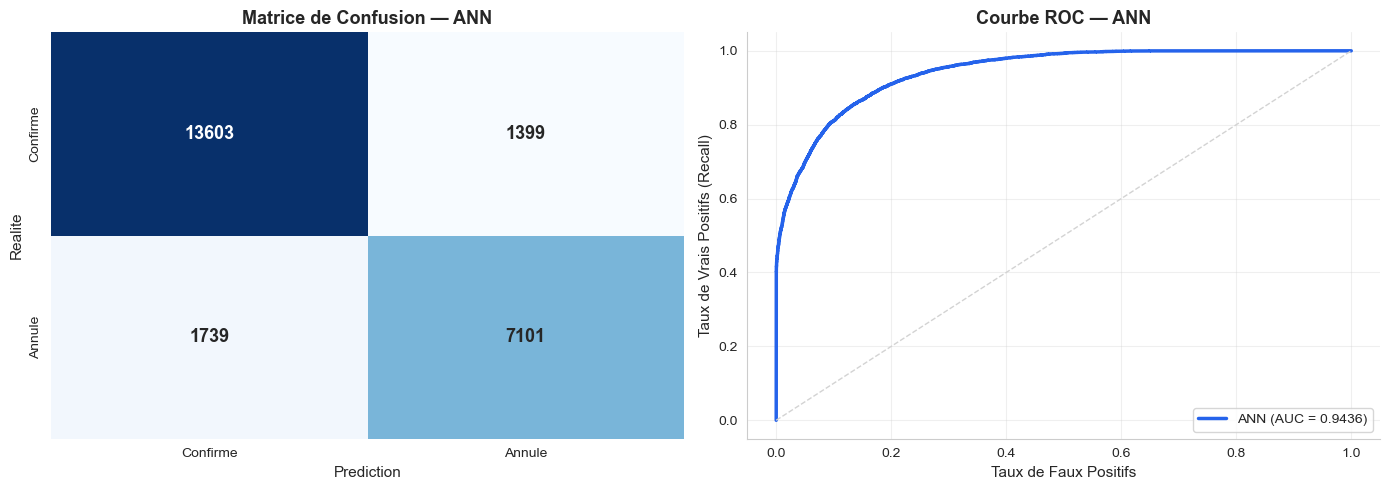

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Confirme', 'Annule'],
            yticklabels=['Confirme', 'Annule'],
            cbar=False, ax=axes[0], annot_kws={'size': 13, 'weight': 'bold'})
axes[0].set_title('Matrice de Confusion — ANN')
axes[0].set_ylabel('Realite')
axes[0].set_xlabel('Prediction')

# Courbe ROC ANN
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_pred_proba)
roc_auc_ann = auc(fpr_ann, tpr_ann)
axes[1].plot(fpr_ann, tpr_ann, color=CONFIG['color_secondary'], lw=2.5,
             label=f'ANN (AUC = {roc_auc_ann:.4f})')
axes[1].plot([0, 1], [0, 1], color='lightgray', linestyle='--', lw=1)
axes[1].set_xlabel('Taux de Faux Positifs')
axes[1].set_ylabel('Taux de Vrais Positifs (Recall)')
axes[1].set_title('Courbe ROC — ANN')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['assets_dir'], 'confusion_matrix_ann.png'),
            dpi=150, bbox_inches='tight')
plt.show()

**Lecture de la matrice de confusion :**

| Cellule | Signification | Impact metier |
|---------|---------------|---------------|
| Vrai Negatif (haut-gauche) | Confirmees correctement identifiees | Pas d'action requise |
| Faux Positif (haut-droite) | Confirmations predites comme annulations | Risque de surbooking inutile |
| Faux Negatif (bas-gauche) | Annulations manquees | Chambre vide non relouee (cout le plus eleve) |
| Vrai Positif (bas-droite) | Annulations correctement identifiees | Action preventive possible |

**Lecon metier.** Dans la plupart des contextes hoteliers, le **Faux Negatif est plus couteux** : une chambre laissee vide est une perte de revenu certaine, tandis qu'un Faux Positif (qui pousse a surbooker legerement) reste genable. Si cette logique s'applique, on peut **abaisser le seuil de decision** de 0.5 a 0.4 pour augmenter le Recall au detriment de la Precision — un arbitrage a regler avec l'equipe Revenue Management.

**Lecture de la courbe ROC :** La courbe ROC montre le trade-off entre le taux de vrais positifs (Recall) et le taux de faux positifs pour tous les seuils de decision possibles. Un AUC proche de 1 indique une excellente discrimination — le modele classe presque parfaitement les annulations des confirmations quel que soit le seuil choisi.

### 5.7 Sauvegarde des artefacts

In [131]:
# Sauvegarde du modele ANN
ann_model.save(os.path.join(CONFIG['models_dir'], 'ann_model.h5'))

# Sauvegarde de l'historique d'entrainement
history_to_save = {k: [float(v) for v in vals] for k, vals in history.history.items()}
with open(os.path.join(CONFIG['models_dir'], 'training_history.json'), 'w') as f:
    json.dump(history_to_save, f, indent=2)

# Sauvegarde du scaler et de l'encodeur (si pas encore fait en Section 4)
# (ces sauvegardes sont normalement faites dans la section 4)
import joblib
joblib.dump(scaler,          os.path.join(CONFIG['models_dir'], 'scaler.pkl'))
joblib.dump(country_encoder, os.path.join(CONFIG['models_dir'], 'label_encoder_country.pkl'))
joblib.dump(feature_columns, os.path.join(CONFIG['models_dir'], 'feature_columns.pkl'))

print("Artefacts sauvegardes dans models/ :")
for fname in ['ann_model.h5', 'scaler.pkl', 'label_encoder_country.pkl',
              'feature_columns.pkl', 'training_history.json']:
    fpath = os.path.join(CONFIG['models_dir'], fname)
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  {fname:<35} ({size_kb:>8.1f} Ko)")

Artefacts sauvegardes dans models/ :
  ann_model.h5                        (   295.5 Ko)
  scaler.pkl                          (     4.6 Ko)
  label_encoder_country.pkl           (     2.2 Ko)
  feature_columns.pkl                 (     1.7 Ko)
  training_history.json               (    16.1 Ko)


---

## Section 6 — Importance des Features

L'ANN etant un modele **boite noire**, il est impossible d'extraire directement l'importance des features depuis ses poids. Nous utilisons donc un **Random Forest** entraine sur les memes donnees pour obtenir une mesure d'importance interpretable.

Cette technique est recommandee par l'etude XAI Stories (Biecek et al.) pour interpreter les predictions d'ANN : le Random Forest joue le role de **modele proxy interpretable**, ses importances de features etant correlees avec celles apprises par l'ANN.

### 6.1 Entrainement du Random Forest pour l'interpretabilite

In [133]:
# Entrainement d'un Random Forest sur les donnees preprocessees
# Uniquement pour extraire l'importance des features — pas comme modele de prediction
rf_interpretability = RandomForestClassifier(
    n_estimators=100,
    random_state=CONFIG['random_state'],
    n_jobs=-1
)
rf_interpretability.fit(X_train_resampled, y_train_resampled)

# Verification rapide de la performance RF (reference pour valider la coherence)
rf_pred = rf_interpretability.predict(X_test_scaled)
rf_acc  = accuracy_score(y_test, rf_pred)
print(f"Random Forest (reference) — Accuracy : {rf_acc:.4f}")
print(f"ANN (modele principal)    — Accuracy : {ann_accuracy:.4f}")

Random Forest (reference) — Accuracy : 0.8928
ANN (modele principal)    — Accuracy : 0.8684


In [134]:
# Extraction et tri de l'importance des features
feature_importance = pd.DataFrame({
    'Feature':    feature_columns,
    'Importance': rf_interpretability.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

top_n = 20
top_features = feature_importance.head(top_n)
print(f"Top {top_n} features par importance (Random Forest proxy) :")
print(top_features.to_string(index=False))

Top 20 features par importance (Random Forest proxy) :
                     Feature  Importance
                   lead_time    0.110098
             country_encoded    0.104465
     deposit_type_Non Refund    0.085016
                         adr    0.056558
   total_of_special_requests    0.044357
           room_type_changed    0.042510
                       agent    0.042188
   arrival_date_day_of_month    0.039944
    arrival_date_week_number    0.039798
        has_special_requests    0.033454
                 total_stays    0.031107
             arrival_weekday    0.028009
        stays_in_week_nights    0.027126
 required_car_parking_spaces    0.024776
           arrival_date_year    0.023864
    market_segment_Online TA    0.023001
      previous_cancellations    0.022912
     customer_type_Transient    0.018852
market_segment_Offline TA/TO    0.017172
     stays_in_weekend_nights    0.016455


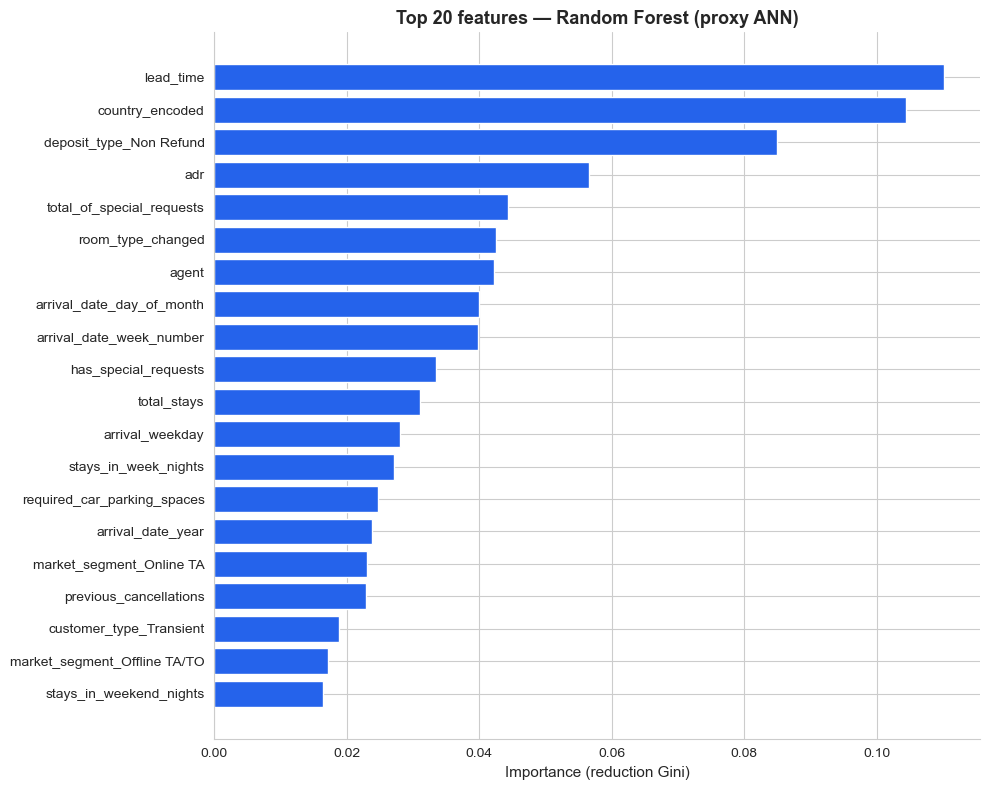

In [135]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_features['Feature'][::-1], top_features['Importance'][::-1],
        color=CONFIG['color_secondary'], edgecolor='white')
ax.set_xlabel('Importance (reduction Gini)')
ax.set_title(f'Top {top_n} features — Random Forest (proxy ANN)')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['assets_dir'], 'feature_importance.png'),
            dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Interpretation et confrontation a la litterature

**Features attendues comme dominantes (consensus litterature) :**

- **`lead_time`** — Consensus absolu (Antonio 2019, Herrera 2024, XAI Stories). Plus la reservation est anticipee, plus le risque d'annulation est eleve. Relation non lineaire : le risque augmente exponentiellement apres 100 jours.
- **`deposit_type_Non_Refund`** — Antonio 2019, Herrera 2024. Paradoxe statistique : les depots non remboursables sont associes aux plus forts taux d'annulation (causalite inversee — politique appliqueee aux reservations a risque).
- **`adr` (Average Daily Rate)** — Etudes bayesiennes (arxiv 2024). Reservations coutuses = clients plus volatils ou reflexion plus longue.
- **`total_of_special_requests`** — Etudes bayesiennes (arxiv 2024). Engagement fort du client = faible risque. Ne jamais supprimer cette feature.
- **`country_encoded`** — XAI Stories. Le pays d'origine du client reflte des comportements culturels differents face aux annulations.
- **`market_segment_*`** — Herrera 2024. Les OTA (Online TA) concentrent les clients les plus volatils.

**Validation de coherence :** Si les top features observees correspondent a cette liste, le modele ANN apprend des signaux pertinents et non du bruit. Une divergence majeure justifierait une investigation (preprocessing different, biais d'echantillonnage, version du dataset).

---

## Section 7 — Conclusion et Recommandations

### 7.1 Synthese des performances ANN

In [138]:
# Tableau de synthese final — ANN uniquement
ann_results = pd.DataFrame([{
    'Modele':     'ANN (Reseau de Neurones)',
    'Accuracy':   round(ann_accuracy, 4),
    'Precision':  round(ann_precision, 4),
    'Recall':     round(ann_recall, 4),
    'F1-Score':   round(ann_f1, 4),
    'ROC-AUC':    round(ann_roc_auc, 4),
    'Architecture': '128-64-32 + BatchNorm + Dropout',
    'Epochs':     len(history.history['loss']),
}])

print("Resultats finaux du modele ANN :")
print(ann_results.to_string(index=False))

# Sauvegarde pour l'application Streamlit
ann_results.rename(columns={'Modele': 'Model'}).to_csv(
    os.path.join(CONFIG['models_dir'], 'model_comparison.csv'), index=False
)
print(f"\nResultats sauvegardes : {CONFIG['models_dir']}/model_comparison.csv")

Resultats finaux du modele ANN :
                  Modele  Accuracy  Precision  Recall  F1-Score  ROC-AUC                    Architecture  Epochs
ANN (Reseau de Neurones)    0.8684      0.861   0.855    0.8578   0.9436 128-64-32 + BatchNorm + Dropout     100

Resultats sauvegardes : models/model_comparison.csv
